### Combine player_start_comparsion

In [ ]:
import numpy as np
import pandas as pd


## Effect of starting player

In [24]:
lab_df = pd.read_csv("Combined.csv")
start_df = pd.read_csv("player_start_comp_combined.csv")
# start_df['player_id'] = start_df['player_id'].astype(int)

In [25]:
final_df = lab_df.merge(
    start_df[['player_id','started_first']],
    left_on='participant',
    right_on='player_id',
    how='left'
)

In [26]:
final_df = final_df.drop(columns='player_id')

In [28]:
final_df.to_csv("Combined_results_with_start_order.csv", index=False)

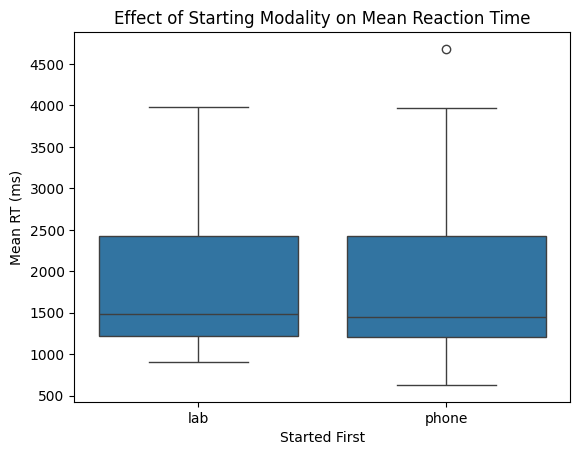

In [29]:
final_df.to_csv("lab_results_with_start_order.csv", index=False)
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=final_df, x='started_first', y='RT_mean(ms)')
plt.title('Effect of Starting Modality on Mean Reaction Time')
plt.ylabel('Mean RT (ms)')
plt.xlabel('Started First')
plt.show()

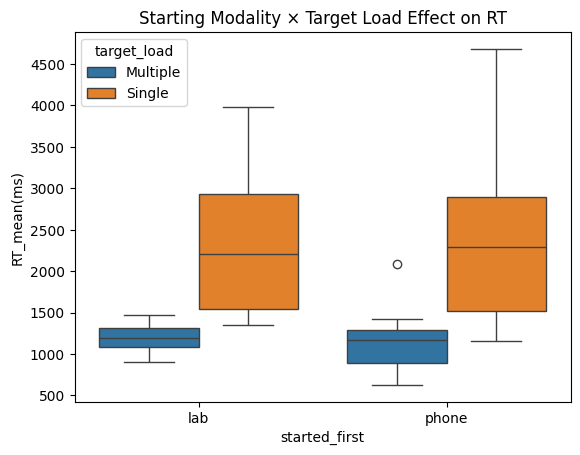

In [30]:
sns.boxplot(data=final_df, x='started_first', y='RT_mean(ms)', hue='target_load')
plt.title('Starting Modality × Target Load Effect on RT')
plt.show()

In [31]:
from scipy.stats import ttest_ind

phone_first = final_df[final_df.started_first == 'phone']['RT_mean(ms)']
lab_first = final_df[final_df.started_first == 'lab']['RT_mean(ms)']

ttest_ind(phone_first, lab_first)

TtestResult(statistic=np.float64(-0.058513581504834135), pvalue=np.float64(0.9535016418572114), df=np.float64(72.0))

In [32]:
phone_first_acc = final_df[final_df.started_first == 'phone']['Accuracy_mean']
lab_first_acc = final_df[final_df.started_first == 'lab']['Accuracy_mean']

ttest_ind(phone_first_acc, lab_first_acc)

TtestResult(statistic=np.float64(0.3748624822034143), pvalue=np.float64(0.7088646681326234), df=np.float64(72.0))

In [33]:
final_df.groupby('started_first')[['RT_mean(ms)','Accuracy_mean']].mean()

,RT_mean(ms),Accuracy_mean
started_first,,
lab,1816.331289,0.979111
phone,1803.773132,0.982348


<Axes: xlabel='started_first', ylabel='RT_mean(ms)'>

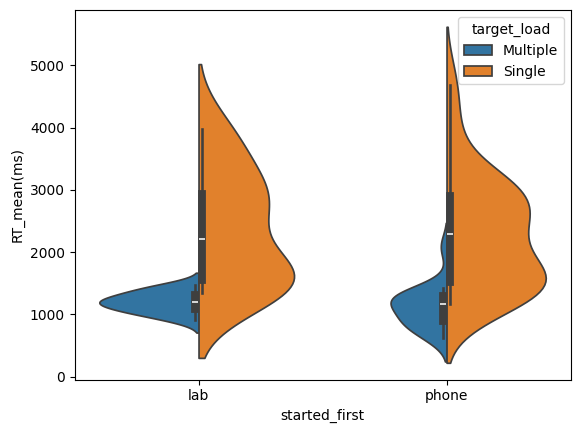

In [34]:
sns.violinplot(data=final_df, x='started_first', y='RT_mean(ms)', hue='target_load', split=True)